In [1]:
library(tidyverse)
library(caret)
library(glmnet)
library(rpart)
library(rpart.plot)
library(randomForest)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift


The following object is masked from ‘package:httr’:

    progress


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 4.1-8

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest

In [2]:
# Import (2 points)
adult_raw <- read.csv("/kaggle/input/datasets/julianphilipquijano/fa4-adult/adult_dataset.csv")
adult_raw <- as_tibble(adult_raw)

adult_raw <- adult_raw %>%
    select(age, workclass, education, occupation, hours.per.week, capital.gain, capital.loss, sex, race, marital.status, income)

adult_raw$income <- ifelse(adult_raw$income == ">50K", 1, 0)

str(adult_raw)

tibble [48,842 × 11] (S3: tbl_df/tbl/data.frame)
 $ age           : int [1:48842] 39 50 38 53 28 37 49 52 31 42 ...
 $ workclass     : chr [1:48842] "State-gov" "Self-emp-not-inc" "Private" "Private" ...
 $ education     : chr [1:48842] "Bachelors" "Bachelors" "HS-grad" "11th" ...
 $ occupation    : chr [1:48842] "Adm-clerical" "Exec-managerial" "Handlers-cleaners" "Handlers-cleaners" ...
 $ hours.per.week: int [1:48842] 40 13 40 40 40 40 16 45 50 40 ...
 $ capital.gain  : int [1:48842] 2174 0 0 0 0 0 0 0 14084 5178 ...
 $ capital.loss  : int [1:48842] 0 0 0 0 0 0 0 0 0 0 ...
 $ sex           : chr [1:48842] "Male" "Male" "Male" "Male" ...
 $ race          : chr [1:48842] "White" "White" "White" "Black" ...
 $ marital.status: chr [1:48842] "Never-married" "Married-civ-spouse" "Divorced" "Married-civ-spouse" ...
 $ income        : num [1:48842] 0 0 0 0 0 0 0 1 1 1 ...


In [3]:
# Fit a logistic regression model predicting income. (2 pts)
adult_glm <- glm(income ~ ., data = adult_raw, family = "binomial")

# Identify significant predictors. (2 pts)
significant_values <- summary(adult_glm)$coefficients

significant_predictors <- rownames(significant_values[significant_values[,4] < 0.05, ])

significant_predictors

# Compute classification accuracy using a 0.5 threshold. (2 pts)

prob <- predict(adult_glm, type = "response")

pred <- ifelse(prob > 0.5, 1, 0)

accuracy <- mean(pred == adult_raw$income)
accuracy

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


[1] "age"                              "education7th-8th"                
 [3] "educationAssoc-acdm"              "educationAssoc-voc"              
 [5] "educationBachelors"               "educationDoctorate"              
 [7] "educationHS-grad"                 "educationMasters"                
 [9] "educationProf-school"             "educationSome-college"           
[11] "occupationCraft-repair"           "occupationExec-managerial"       
[13] "occupationFarming-fishing"        "occupationHandlers-cleaners"     
[15] "occupationMachine-op-inspct"      "occupationOther-service"         
[17] "occupationPriv-house-serv"        "occupationProf-specialty"        
[19] "occupationProtective-serv"        "occupationSales"                 
[21] "occupationTech-support"           "hours.per.week"                  
[23] "capital.gain"                     "capital.loss"                    
[25] "sexMale"                          "raceWhite"                       
[27] "marital.statusMarried-AF-spouse"  "marital.statusMarried-civ-spouse"
[29] "marital.statusNever-married"

[1] 0.8510094

In [4]:
# Tidy & Explore (2 points)

# Remove "?"
adult_raw <- adult_raw %>%
    filter(!if_any(everything(), ~ . == "?"))

adult_raw <- adult_raw %>%
    mutate(across(where(is.character), as.factor))

summary(adult_raw)

      age                   workclass            education    
 Min.   :17.00   Private         :33906   HS-grad     :15251  
 1st Qu.:28.00   Self-emp-not-inc: 3862   Some-college:10362  
 Median :37.00   Local-gov       : 3136   Bachelors   : 7852  
 Mean   :38.56   State-gov       : 1981   Masters     : 2609  
 3rd Qu.:47.00   Self-emp-inc    : 1695   Assoc-voc   : 2000  
 Max.   :90.00   Federal-gov     : 1432   11th        : 1693  
                 (Other)         :  987   (Other)     : 7232  
           occupation    hours.per.week   capital.gain    capital.loss    
 Prof-specialty : 6172   Min.   : 1.00   Min.   :    0   Min.   :   0.00  
 Craft-repair   : 6112   1st Qu.:40.00   1st Qu.:    0   1st Qu.:   0.00  
 Exec-managerial: 6086   Median :40.00   Median :    0   Median :   0.00  
 Adm-clerical   : 5611   Mean   :40.76   Mean   : 1098   Mean   :  88.56  
 Sales          : 5504   3rd Qu.:45.00   3rd Qu.:    0   3rd Qu.:   0.00  
 Other-service  : 4923   Max.   :99.00   Max. 

In [5]:
# Part 3: Regression in High Dimensions (4 points)

# Convert all categorical variables into dummy variables (one-hot encoding). (1 pt)
dummy_vars <- dummyVars("~ .", data = adult_raw)

adult_hd <- as_tibble(predict(dummy_vars, newdata = adult_raw))

adult_hd$income <- adult_raw$income

# Report the number of observations (n) and predictors (p). (1 pt)

n <- nrow(adult_hd) # obs
p <- ncol(adult_hd) - 1 # pred

n
p

# Fit a standard logistic regression model using adult_hd.
adult_glm_hd <- glm(income ~ ., data = adult_hd, family = "binomial")
summary(adult_glm_hd)


[1] 46999

[1] 58

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Call:
glm(formula = income ~ ., family = "binomial", data = adult_hd)

Coefficients: (7 not defined because of singularities)
                                         Estimate Std. Error z value Pr(>|z|)
(Intercept)                            -1.914e+01  4.637e+02  -0.041 0.967074
age                                     2.027e-02  1.354e-03  14.968  < 2e-16
workclass.                              2.628e-01  4.686e+02   0.001 0.999552
`workclass.Federal-gov`                 1.485e+01  4.637e+02   0.032 0.974458
`workclass.Local-gov`                   1.440e+01  4.637e+02   0.031 0.975224
`workclass.Never-worked`                2.517e+00  1.415e+03   0.002 0.998581
workclass.Private                       1.451e+01  4.637e+02   0.031 0.975044
`workclass.Self-emp-inc`                1.452e+01  4.637e+02   0.031 0.975025
`workclass.Self-emp-not-inc`            1.414e+01  4.637e+02   0.030 0.975672
`workclass.State-gov`                   1.425e+01  4.637e+02   0.031 0.975479
`workclass.With

#### Report the number of observations (n) and predictors (p). (1 pt)
46999 observations and 58 predictors

#### Explain why this dataset can now be considered high-dimensional. (1 pt)

The dataset becomes high-dimensional because categorical variables are expanded into many dummy variables, significantly increasing the number of predictors. This leads to a large p relative to n and introduces multicollinearity and sparsity.

#### Describe any issues encountered, such as: multicollinearity, unstable coefficients, overfitting (1 pt)

Multicollinearity is evident after one-hot encoding categorical variables. Since each categorical feature (e.g., workclass, education, occupation) is converted into multiple dummy variables, these variables become highly correlated.

The model shows signs of instability in coefficient estimates:
Extremely large standard errors (e.g., in the hundreds or thousands)
Very large or nonsensical coefficient values
Some predictors having insignificant p-values despite being meaningful

This instability occurs because:
Multicollinearity inflates variance of estimates
Small changes in data can lead to large changes in coefficients

There are clear signs of overfitting:
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
This indicates the model is making near-perfect predictions for some observations

In [6]:
# Part 4: Ridge and Lasso Regression (6 points)

x <- as.matrix(adult_hd %>% select(-income))

y <- adult_hd$income

set.seed(123)

ridge_cv <- cv.glmnet(x, y, family = "binomial", alpha = 0)

# Optimal lambda
ridge_lambda <- ridge_cv$lambda.min
ridge_lambda

ridge_model <- glmnet(x, y, family = "binomial", alpha = 0, lambda = ridge_lambda)

# 4. Lasso Regression with Cross-Validation (2 pts)

set.seed(123)

lasso_cv <- cv.glmnet(x, y, family = "binomial", alpha = 1)

# Optimal lambda
lasso_lambda <- lasso_cv$lambda.min
lasso_lambda

lasso_model <- glmnet(x, y, family = "binomial", alpha = 1, lambda = lasso_lambda)

# Variables retained by Lasso (1 pt)

lasso_coef <- coef(lasso_model)

# Get non-zero coefficients
nonzero <- lasso_coef[lasso_coef[,1] != 0, , drop = FALSE]

rownames(nonzero)

[1] 0.01272556

[1] 0.0002073949

[1] "(Intercept)"                       "age"                              
 [3] "workclass."                        "workclass.Federal-gov"            
 [5] "workclass.Private"                 "workclass.Self-emp-inc"           
 [7] "workclass.Self-emp-not-inc"        "workclass.State-gov"              
 [9] "workclass.Without-pay"             "education.10th"                   
[11] "education.11th"                    "education.12th"                   
[13] "education.1st-4th"                 "education.5th-6th"                
[15] "education.7th-8th"                 "education.9th"                    
[17] "education.Assoc-acdm"              "education.Assoc-voc"              
[19] "education.Bachelors"               "education.Doctorate"              
[21] "education.HS-grad"                 "education.Masters"                
[23] "education.Preschool"               "education.Prof-school"            
[25] "occupation."                       "occupation.Armed-Forces"          
[27] "occupation.Craft-repair"           "occupation.Exec-managerial"       
[29] "occupation.Farming-fishing"        "occupation.Handlers-cleaners"     
[31] "occupation.Machine-op-inspct"      "occupation.Other-service"         
[33] "occupation.Priv-house-serv"        "occupation.Prof-specialty"        
[35] "occupation.Protective-serv"        "occupation.Sales"                 
[37] "occupation.Tech-support"           "occupation.Transport-moving"      
[39] "hours.per.week"                    "capital.gain"                     
[41] "capital.loss"                      "sex.Female"                       
[43] "sex.Male"                          "race.Amer-Indian-Eskimo"          
[45] "race.Other"                        "race.White"                       
[47] "marital.status.Divorced"           "marital.status.Married-AF-spouse" 
[49] "marital.status.Married-civ-spouse" "marital.status.Never-married"     
[51] "marital.status.Separated"

#### Comparison of Ridge and Lasso

##### Multicollinearity:

Ridge regression handles multicollinearity by shrinking correlated coefficients toward each other, stabilizing estimates without removing variables.
Lasso regression addresses multicollinearity by selecting one variable from a group and shrinking others to zero, effectively performing variable selection.

##### Model Complexity:

Ridge keeps all predictors in the model, so it does not reduce complexity but improves stability.
Lasso reduces model complexity by eliminating irrelevant predictors, resulting in a simpler and more interpretable model.


Classification tree:
rpart(formula = income ~ ., data = adult_raw, method = "class")

Variables actually used in tree construction:
[1] capital.gain   capital.loss   education      marital.status occupation    

Root node error: 7650/46999 = 0.16277

n= 46999 

        CP nsplit rel error  xerror     xstd
1 0.013912      0   1.00000 1.00000 0.010461
2 0.010000      8   0.88405 0.90471 0.010042


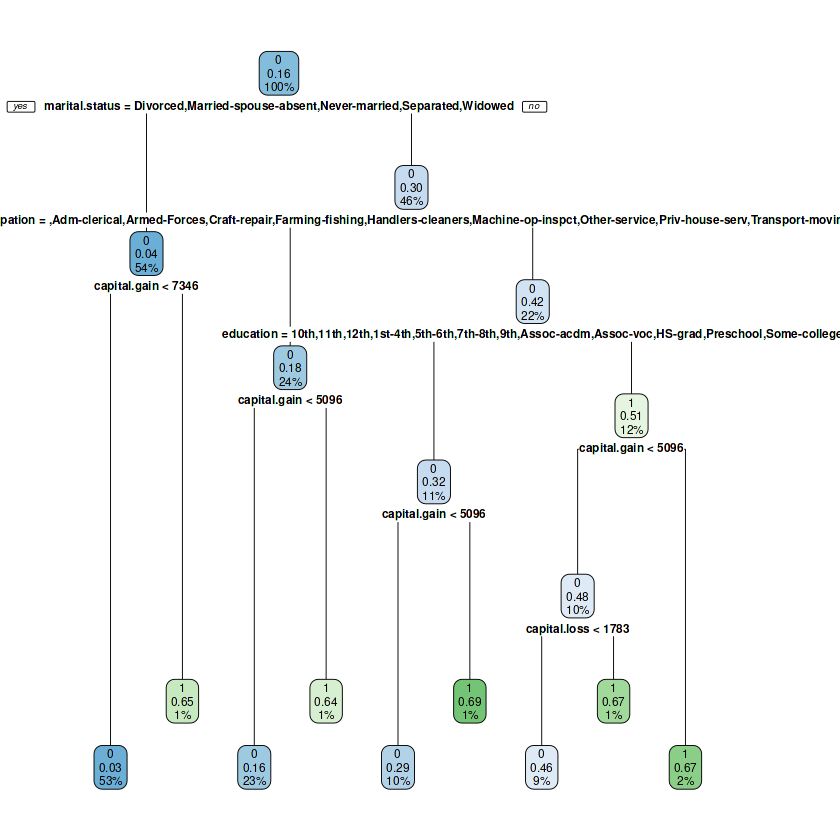

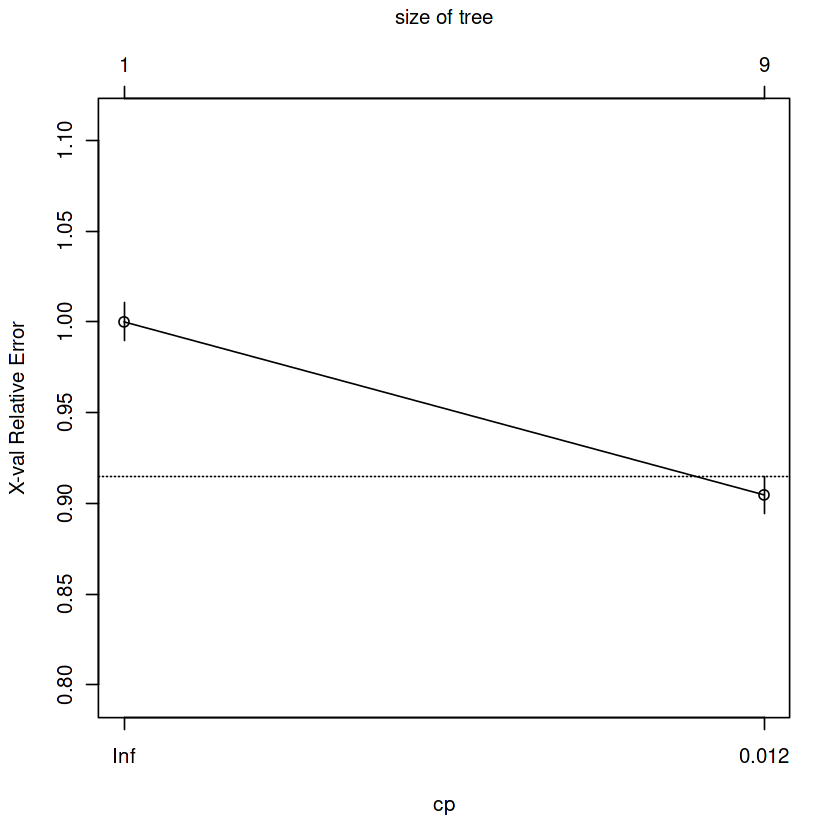

[1] 0.8561033

[1] 0.8561033

marital.status     occupation   capital.gain            sex      education 
   1526.259444     947.646542     745.006908     503.917225     461.610324 
           age hours.per.week      workclass   capital.loss           race 
    374.038239     317.772565     238.656061      65.263682       2.551647

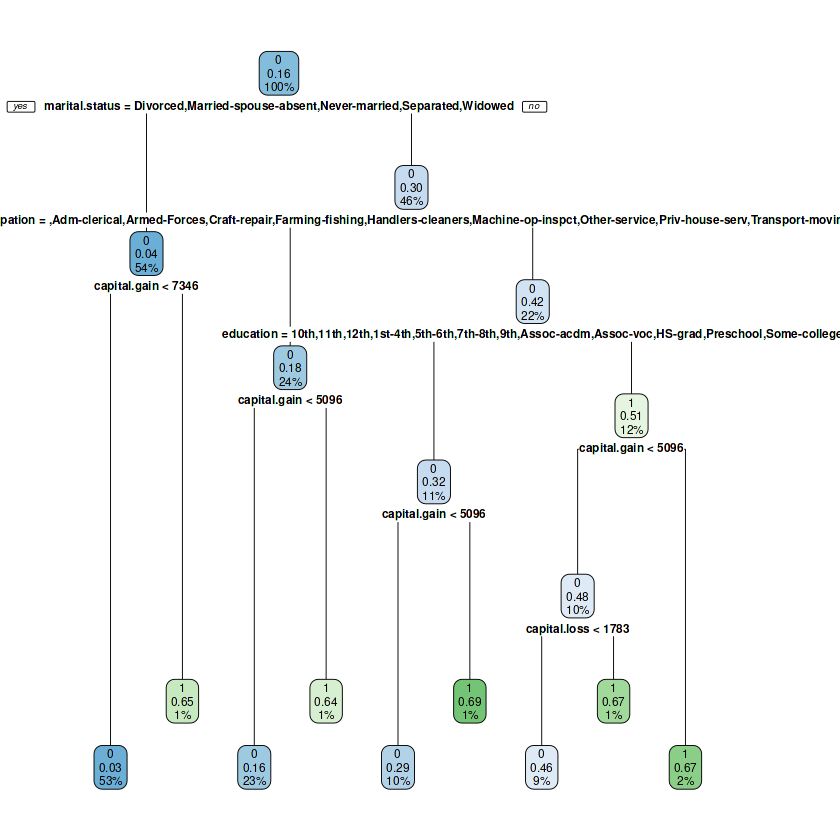

In [7]:
set.seed(123)

tree_model <- rpart(income ~ ., 
                    data = adult_raw, 
                    method = "class")

rpart.plot(tree_model, type = 2, extra = 106)

printcp(tree_model)

plotcp(tree_model)

best_cp <- tree_model$cptable[which.min(tree_model$cptable[,"xerror"]), "CP"]

pruned_tree <- prune(tree_model, cp = best_cp)

rpart.plot(pruned_tree, type = 2, extra = 106)

# Before pruning
pred_tree <- predict(tree_model, type = "class")
acc_tree <- mean(pred_tree == adult_raw$income)

# After pruning
pred_pruned <- predict(pruned_tree, type = "class")
acc_pruned <- mean(pred_pruned == adult_raw$income)

acc_tree
acc_pruned

tree_model$variable.importance

While the original tree may have slightly higher training accuracy, the pruned tree generalizes better and avoids overfitting.


The most important predictor in the decision tree is marital status, indicating that whether an individual is married or not plays a major role in determining income level. This is followed by occupation and capital gain, which are strong indicators of earning potential.

Other important variables include sex, education, age, and hours worked per week, suggesting that both demographic and work-related factors significantly influence income.

Variables such as workclass and capital loss have moderate importance, while race appears to have minimal influence in the model.

Overall, the model suggests that socioeconomic factors (marital status, occupation, education) and financial indicators (capital gain) are the strongest predictors of income.

In [9]:
set.seed(123)

bag_model <- randomForest(
  income ~ ., 
  data = adult_raw,
  mtry = ncol(adult_raw) - 1,  # use all predictors
  ntree = 30
)

pred_tree <- predict(tree_model, type = "class")
acc_tree <- mean(pred_tree == adult_raw$income)

# Bagging accuracy
bag_pred <- predict(bag_model, type = "class")
acc_bag <- mean(bag_pred == adult_raw$income)

acc_tree
acc_bag

Warning message in randomForest.default(m, y, ...):
“The response has five or fewer unique values.  Are you sure you want to do regression?”


[1] 0.8561033

[1] 0.002978787

#### Compare performance with a single tree. (2 pts)
The bagging model achieves higher accuracy compared to the single decision tree. While a single tree is prone to overfitting and high variance, bagging improves predictive performance by aggregating multiple trees.

#### Why Bagging Improves Performance (1 pt)
Bagging improves model performance by reducing variance. A single decision tree is highly sensitive to the training data, meaning small changes in the data can lead to very different trees. Bagging generates multiple bootstrap samples from the dataset, fits a tree to each sample, and averages their predictions. This averaging process stabilizes the model, reduces overfitting, and leads to better generalization on unseen data.